In [20]:
# ============================================================
# Отдельный эксперимент: KAN vs SIREN на Feynman
# KAN — чистый кановский вывод (first-layer phi_j(x_j))
# SIREN — умная MLP (специально для oscillatory/гладких функций)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import math
warnings.filterwarnings("ignore")

DEVICE = torch.device("cpu")  # KAN на маленьких данных быстро обучается на CPU
print("Device:", DEVICE)

Device: cpu


In [21]:
class KANLinear(nn.Module):
    def __init__(
        self, in_features, out_features,
        grid_size=8, spline_order=3,
        scale_noise=0.05, scale_base=1.0, scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=nn.SiLU,
        grid_range=(-3.0, 3.0)
    ):
        super().__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.grid_range = grid_range

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            torch.arange(
                -spline_order,
                grid_size + spline_order + 1,
                dtype=torch.float32
            ) * h + grid_range[0]
        ).expand(in_features, -1).contiguous()

        self.register_buffer("grid", grid)

        self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.empty(
                out_features,
                in_features,
                grid_size + spline_order
            )
        )

        if enable_standalone_scale_spline:
            self.spline_scaler = nn.Parameter(torch.empty(out_features, in_features))

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)

        with torch.no_grad():
            noise = (
                (torch.rand(
                    self.grid_size + 1,
                    self.in_features,
                    self.out_features
                ) - 0.5)
                * self.scale_noise / self.grid_size
            )

            self.spline_weight.copy_(
                self.curve2coeff(
                    self.grid.T[self.spline_order:-self.spline_order],
                    noise
                )
            )

            if self.enable_standalone_scale_spline:
                nn.init.kaiming_uniform_(
                    self.spline_scaler,
                    a=math.sqrt(5) * self.scale_spline
                )

    def b_splines(self, x):
        grid = self.grid
        x = x.unsqueeze(-1)

        bases = (
            (x >= grid[:, :-1]) &
            (x < grid[:, 1:])
        ).to(x.dtype)

        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, :-(k + 1)])
                / (grid[:, k:-1] - grid[:, :-(k + 1)])
            ) * bases[:, :, :-1] + (
                (grid[:, k + 1:] - x)
                / (grid[:, k + 1:] - grid[:, 1:(-k)])
            ) * bases[:, :, 1:]

        return bases.contiguous()

    def curve2coeff(self, x, y):
        A = self.b_splines(x).transpose(0, 1)
        B = y.transpose(0, 1)
        solution = torch.linalg.lstsq(A, B).solution
        return solution.permute(2, 0, 1).contiguous()

    @property
    def scaled_spline_weight(self):
        if self.enable_standalone_scale_spline:
            return self.spline_weight * self.spline_scaler.unsqueeze(-1)
        return self.spline_weight

    def forward(self, x):
        base = F.linear(self.base_activation(x), self.base_weight)

        spline = F.linear(
            self.b_splines(x).reshape(x.size(0), -1),
            self.scaled_spline_weight.reshape(self.out_features, -1)
        )

        return base + spline


class KAN(nn.Module):
    def __init__(self, layers_hidden, grid_size=8, spline_order=3):
        super().__init__()
        self.layers = nn.ModuleList([
            KANLinear(
                a, b,
                grid_size=grid_size,
                spline_order=spline_order
            )
            for a, b in zip(layers_hidden, layers_hidden[1:])
        ])

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class FeatureWiseKANEncoder(nn.Module):
    def __init__(self, n_features, d_model=64, hidden_dim=4):
        super().__init__()
        self.models = nn.ModuleList([
            KAN([1, hidden_dim, d_model])
            for _ in range(n_features)
        ])

    def forward(self, x):
        tokens = [
            model(x[:, i:i+1]).unsqueeze(1)
            for i, model in enumerate(self.models)
        ]
        return torch.cat(tokens, dim=1)


class FeatureWiseMLPEncoder(nn.Module):
    def __init__(self, n_features, d_model=64, hidden_dim=16):
        super().__init__()
        self.models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(1, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.GELU(),
                nn.Linear(hidden_dim, d_model),
            )
            for _ in range(n_features)
        ])

    def forward(self, x):
        tokens = [
            model(x[:, i:i+1]).unsqueeze(1)
            for i, model in enumerate(self.models)
        ]
        return torch.cat(tokens, dim=1)

In [22]:
# ============================================================
# Feynman: загрузка формул и генерация данных
# ============================================================

FEYNMAN_URL = (
    "https://huggingface.co/spaces/MilesCranmer/PySR/resolve/"
    "6e2fc47a46ef3c644c333a73d17fcc4b5d9c115f/datasets/FeynmanEquations.csv"
)

def load_feynman_catalog(url=FEYNMAN_URL):
    return pd.read_csv(url)


def safe_formula_eval(formula, variables, X):
    """Безопасно вычисляет формулу на массиве X (N, n_var)."""
    local = {
        "sqrt": np.sqrt, "exp": np.exp, "sin": np.sin, "cos": np.cos,
        "tan": np.tan, "log": np.log, "ln": np.log, "log10": np.log10,
        "abs": np.abs, "Abs": np.abs, "arcsin": np.arcsin,
        "arccos": np.arccos, "arctan": np.arctan, "sinh": np.sinh,
        "cosh": np.cosh, "tanh": np.tanh, "pi": np.pi, "E": np.e,
        "G": 1.0,
    }
    for j, var in enumerate(variables):
        local[var] = X[:, j]
    return np.asarray(eval(formula, {"__builtins__": {}}, local), dtype=float)


def load_feynman_equation(row, n_samples=5000, seed=42):
    """Генерирует данные из Feynman-формулы."""
    nvar = int(row["# variables"])
    variables = [row[f"v{i}_name"] for i in range(1, nvar + 1)]
    lows  = [float(row[f"v{i}_low"])  for i in range(1, nvar + 1)]
    highs = [float(row[f"v{i}_high"]) for i in range(1, nvar + 1)]

    rng = np.random.default_rng(seed)
    X = np.column_stack([
        rng.uniform(lo, hi, size=n_samples)
        for lo, hi in zip(lows, highs)
    ])

    y = safe_formula_eval(row["Formula"], variables, X)

    # Отбрасываем нечисловые/бесконечные
    mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[mask], y[mask]

    # Если динамический диапазон огромный — клипуем хвосты
    q01, q99 = np.percentile(y, [1, 99])
    if q99 - q01 > 0 and abs(q99) / max(abs(q01), 1e-12) > 1e6:
        y = np.clip(y, q01, q99)

    meta = {
        "id": row["Filename"],
        "formula": row["Formula"],
        "variables": variables,
        "ranges": list(zip(lows, highs)),
    }
    return X, y, meta


catalog = load_feynman_catalog()
print("Catalog shape:", catalog.shape)
display(catalog[["Filename", "Formula", "# variables"]].head(8))

Catalog shape: (100, 36)


,Filename,Formula,# variables
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),1
1,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2
2,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,3
3,I.8.14,sqrt((x2-x1)**2+(y2-y1)**2),4
4,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),9
5,I.10.7,m_0/sqrt(1-v**2/c**2),3
6,I.11.19,x1*y1+x2*y2+x3*y3,6
7,I.12.1,mu*Nn,2


In [23]:
# ============================================================
# Проверяем, что KANLinear/KAN уже определены.
# Если нет — определяем здесь (те же, что в основном ноутбуке).
# ============================================================

if "KANLinear" not in globals():
    import math

    class KANLinear(nn.Module):
        def __init__(
            self, in_features, out_features,
            grid_size=8, spline_order=3,
            scale_noise=0.05, scale_base=1.0, scale_spline=1.0,
            enable_standalone_scale_spline=True,
            base_activation=nn.SiLU,
            grid_range=(-3.0, 3.0),
        ):
            super().__init__()
            self.in_features = in_features
            self.out_features = out_features
            self.grid_size = grid_size
            self.spline_order = spline_order
            self.grid_range = grid_range

            h = (grid_range[1] - grid_range[0]) / grid_size
            grid = (
                torch.arange(-spline_order, grid_size + spline_order + 1,
                             dtype=torch.float32) * h + grid_range[0]
            ).expand(in_features, -1).contiguous()
            self.register_buffer("grid", grid)

            self.base_weight = nn.Parameter(torch.empty(out_features, in_features))
            self.spline_weight = nn.Parameter(
                torch.empty(out_features, in_features, grid_size + spline_order)
            )
            if enable_standalone_scale_spline:
                self.spline_scaler = nn.Parameter(
                    torch.empty(out_features, in_features)
                )

            self.scale_noise = scale_noise
            self.scale_base = scale_base
            self.scale_spline = scale_spline
            self.enable_standalone_scale_spline = enable_standalone_scale_spline
            self.base_activation = base_activation()
            self.reset_parameters()

        def reset_parameters(self):
            nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
            with torch.no_grad():
                noise = (
                    (torch.rand(self.grid_size + 1, self.in_features, self.out_features) - 0.5)
                    * self.scale_noise / self.grid_size
                )
                self.spline_weight.copy_(
                    self.curve2coeff(self.grid.T[self.spline_order:-self.spline_order], noise)
                )
                if self.enable_standalone_scale_spline:
                    nn.init.kaiming_uniform_(
                        self.spline_scaler, a=math.sqrt(5) * self.scale_spline
                    )

        def b_splines(self, x):
            grid = self.grid
            x = x.unsqueeze(-1)
            bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
            for k in range(1, self.spline_order + 1):
                bases = (
                    (x - grid[:, :-(k + 1)]) / (grid[:, k:-1] - grid[:, :-(k + 1)])
                ) * bases[:, :, :-1] + (
                    (grid[:, k + 1:] - x) / (grid[:, k + 1:] - grid[:, 1:(-k)])
                ) * bases[:, :, 1:]
            return bases.contiguous()

        def curve2coeff(self, x, y):
            A = self.b_splines(x).transpose(0, 1)
            B = y.transpose(0, 1)
            solution = torch.linalg.lstsq(A, B).solution
            return solution.permute(2, 0, 1).contiguous()

        @property
        def scaled_spline_weight(self):
            if self.enable_standalone_scale_spline:
                return self.spline_weight * self.spline_scaler.unsqueeze(-1)
            return self.spline_weight

        def forward(self, x):
            base = F.linear(self.base_activation(x), self.base_weight)
            spline = F.linear(
                self.b_splines(x).reshape(x.size(0), -1),
                self.scaled_spline_weight.reshape(self.out_features, -1),
            )
            return base + spline

    class KAN(nn.Module):
        def __init__(self, layers_hidden, grid_size=8, spline_order=3):
            super().__init__()
            self.layers = nn.ModuleList([
                KANLinear(a, b, grid_size=grid_size, spline_order=spline_order)
                for a, b in zip(layers_hidden, layers_hidden[1:])
            ])

        def forward(self, x):
            for layer in self.layers:
                x = layer(x)
            return x

In [24]:
# ============================================================
# SIREN: MLP с sin-активациями, специально для гладких/oscillatory функций
# ============================================================

class SineLayer(nn.Module):
    """Линейный слой с sin(omega_0 * Wx + b) — базовая единица SIREN."""
    def __init__(self, in_features, out_features, omega_0=30.0, is_first=False):
        super().__init__()
        self.omega_0 = omega_0
        self.linear = nn.Linear(in_features, out_features)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1.0 / in_features, 1.0 / in_features)
            else:
                bound = np.sqrt(6.0 / in_features) / omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class Siren(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=64, n_layers=3, omega_0=30.0):
        super().__init__()
        layers = [SineLayer(in_dim, hidden_dim, omega_0, is_first=True)]
        for _ in range(n_layers - 1):
            layers.append(SineLayer(hidden_dim, hidden_dim, omega_0))
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


In [25]:
# ============================================================
# Обучение KAN([n, hidden, 1]) и SIREN как самостоятельных регрессоров
# ============================================================

def _train_loop(model, Xtr, ytr, Xv, yv,
                epochs, patience, lr, batch_size, device):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=max(10, patience // 3)
    )
    criterion = nn.MSELoss()

    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)

    best_val, best_state, bad = np.inf, None, 0

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xv), yv).item()
        scheduler.step(val_loss)

        if val_loss < best_val - 1e-7:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    model.to(device).eval()
    return model, {"best_val": best_val, "epochs": epoch + 1}


def train_kan_regressor(Xtr, ytr, Xv, yv,
                        hidden_dim=16, grid_size=8, spline_order=3,
                        epochs=300, patience=40, lr=1e-3, batch_size=256,
                        device="cpu"):
    n_features = Xtr.shape[1]

    x_mean, x_std = Xtr.mean(axis=0), Xtr.std(axis=0) + 1e-8
    y_mean, y_std = ytr.mean(), ytr.std() + 1e-8

    Xtr_t = torch.tensor((Xtr - x_mean) / x_std, dtype=torch.float32, device=device)
    ytr_t = torch.tensor((ytr - y_mean) / y_std, dtype=torch.float32, device=device).reshape(-1, 1)
    Xv_t  = torch.tensor((Xv  - x_mean) / x_std, dtype=torch.float32, device=device)
    yv_t  = torch.tensor((yv  - y_mean) / y_std, dtype=torch.float32, device=device).reshape(-1, 1)

    model = KAN([n_features, hidden_dim, 1],
                grid_size=grid_size, spline_order=spline_order).to(device)

    model, info = _train_loop(model, Xtr_t, ytr_t, Xv_t, yv_t,
                              epochs, patience, lr, batch_size, device)

    return model, {"x_mean": x_mean, "x_std": x_std,
                   "y_mean": y_mean, "y_std": y_std, **info}


def train_siren_regressor(Xtr, ytr, Xv, yv,
                          hidden_dim=64, n_layers=3, omega_0=30.0,
                          epochs=300, patience=40, lr=1e-3, batch_size=256,
                          device="cpu"):
    n_features = Xtr.shape[1]

    x_mean, x_std = Xtr.mean(axis=0), Xtr.std(axis=0) + 1e-8
    y_mean, y_std = ytr.mean(), ytr.std() + 1e-8

    Xtr_t = torch.tensor((Xtr - x_mean) / x_std, dtype=torch.float32, device=device)
    ytr_t = torch.tensor((ytr - y_mean) / y_std, dtype=torch.float32, device=device).reshape(-1, 1)
    Xv_t  = torch.tensor((Xv  - x_mean) / x_std, dtype=torch.float32, device=device)
    yv_t  = torch.tensor((yv  - y_mean) / y_std, dtype=torch.float32, device=device).reshape(-1, 1)

    model = Siren(n_features, 1,
                  hidden_dim=hidden_dim, n_layers=n_layers, omega_0=omega_0).to(device)

    model, info = _train_loop(model, Xtr_t, ytr_t, Xv_t, yv_t,
                              epochs, patience, lr, batch_size, device)

    return model, {"x_mean": x_mean, "x_std": x_std,
                   "y_mean": y_mean, "y_std": y_std, **info}


def predict(model, X, meta, device="cpu"):
    xs = (X - meta["x_mean"]) / meta["x_std"]
    with torch.no_grad():
        out = model(torch.tensor(xs, dtype=torch.float32, device=device)).cpu().numpy().reshape(-1)
    return out * meta["y_std"] + meta["y_mean"]


In [26]:
# ============================================================
# ЧИСТЫЙ кановский вывод по признаку j.
#
# Первый слой KAN:  x_j  ->  phi_j(x_j)  ∈ R^{hidden_dim}
# Эта функция НЕ зависит от других входов — структурно.
#
# Здесь мы достаём её из весов KANLinear первого слоя:
#   forward(x) = SiLU(x) @ W_base^T + B_splines(x) @ W_spline^T
# и берём j-й столбец W_base и j-й срез W_spline.
# ============================================================

def kan_first_layer_phi(kan, feature_idx, x_j_tensor):
    """
    Возвращает phi_j(x_j) — выход первого слоя KAN по признаку j.

    Параметры
    ---------
    kan : KAN  (ваш класс)
    feature_idx : int
        Индекс признака (столбец входа).
    x_j_tensor : torch.Tensor, shape (n,)
        Значения признака j (уже стандартизованные).

    Возвращает
    ----------
    phi_j : np.ndarray, shape (n, hidden_dim)
        Вектор-функция, которую KAN выучил для признака j.
    """
    first = kan.layers[0]  # KANLinear(in=n_features, out=hidden_dim)
    x = x_j_tensor.reshape(-1, 1)  # (n, 1)

    with torch.no_grad():
        # --- base part: SiLU(x_j) * W_base[:, j] ---
        # W_base имеет shape (hidden_dim, n_features).
        w_base_j = first.base_weight[:, feature_idx]           # (hidden_dim,)
        base_part = first.base_activation(x) * w_base_j.unsqueeze(0)  # (n, hidden_dim)

        # --- spline part: B_splines(x_j) @ W_spline[:, j, :]^T ---
        # b_splines ожидает полный вход (n, n_features); передаём только x_j на позиции j.
        fake = torch.zeros(x.shape[0], first.in_features, dtype=x.dtype)
        fake[:, feature_idx] = x[:, 0]
        bases = first.b_splines(fake)[:, feature_idx, :]        # (n, n_basis)

        w_spline_j = first.spline_weight[:, feature_idx, :]     # (hidden_dim, n_basis)
        if first.enable_standalone_scale_spline:
            w_spline_j = w_spline_j * first.spline_scaler[:, feature_idx].unsqueeze(-1)
        spline_part = bases @ w_spline_j.T                      # (n, hidden_dim)

        phi_j = base_part + spline_part                         # (n, hidden_dim)

    return phi_j.numpy()


def kan_phi_on_grid(kan, meta, feature_idx, grid_original_scale):
    """
    Обёртка: берёт grid в оригинальной шкале, стандартизует его
    (по сохранённым meta["x_mean"], meta["x_std"]) и возвращает phi_j.
    """
    x_mean = meta["x_mean"][feature_idx]
    x_std  = meta["x_std"][feature_idx]
    grid_scaled = (grid_original_scale - x_mean) / x_std
    x_t = torch.tensor(grid_scaled, dtype=torch.float32)
    return kan_first_layer_phi(kan, feature_idx, x_t)


def full_model_1d_slice(model, meta, feature_idx, grid_original_scale):
    """
    Полный forward модели на 1D-срезе:
      вход = [0, ..., x_j, ..., 0]  (в стандартизованном пространстве)
    где нули соответствуют среднему значению по train.
    Это честный срез полной функции модели (без всяких PDP).
    """
    n_features = meta["x_mean"].shape[0]
    n = len(grid_original_scale)

    x_scaled = np.zeros((n, n_features), dtype=np.float32)
    x_scaled[:, feature_idx] = (
        (grid_original_scale - meta["x_mean"][feature_idx]) / meta["x_std"][feature_idx]
    )

    with torch.no_grad():
        out = model(torch.tensor(x_scaled, dtype=torch.float32)).cpu().numpy().reshape(-1)
    return out * meta["y_std"] + meta["y_mean"]


def exact_1d_slice(meta, feature_idx, grid_original_scale, bg_original):
    """
    Точный 1D-срез формулы F(x_j = v, остальные = bg).
    bg_original — вектор фона в оригинальной шкале
    (обычно x_scaler.mean_ или train mean).
    """
    n = len(grid_original_scale)
    X = np.tile(bg_original, (n, 1))
    X[:, feature_idx] = grid_original_scale
    return safe_formula_eval(meta["formula"], meta["variables"], X)


In [27]:
# ============================================================
# Один Feynman-уравнение: обучение + визуализация
# ============================================================

def run_feynman_kan_vs_siren(row,
                             n_samples=5000,
                             n_points=200,
                             seed=42,
                             kan_epochs=400,
                             siren_epochs=400):
    # ---------- 1. Данные ----------
    X, y, meta = load_feynman_equation(row, n_samples=n_samples, seed=seed)
    n_features = X.shape[1]

    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    te_n = int(0.2 * len(X)); va_n = int(0.15 * len(X))
    te_idx = idx[:te_n]; va_idx = idx[te_n:te_n+va_n]; tr_idx = idx[te_n+va_n:]

    Xtr, ytr = X[tr_idx], y[tr_idx]
    Xv,  yv  = X[va_idx], y[va_idx]
    Xte, yte = X[te_idx], y[te_idx]

    print(f"\n{'='*70}")
    print(f"{meta['id']}: {meta['formula']}")
    print(f"Features: {meta['variables']}  n={len(X)}")

    # ---------- 2. KAN ----------
    kan, kan_meta = train_kan_regressor(
        Xtr, ytr, Xv, yv,
        hidden_dim=16, epochs=kan_epochs, patience=50,
        lr=1e-3, batch_size=256, device=DEVICE,
    )
    kan_pred = predict(kan, Xte, kan_meta, device=DEVICE)

    # ---------- 3. SIREN ----------
    siren, siren_meta = train_siren_regressor(
        Xtr, ytr, Xv, yv,
        hidden_dim=64, n_layers=3, omega_0=30.0,
        epochs=siren_epochs, patience=50,
        lr=1e-3, batch_size=256, device=DEVICE,
    )
    siren_pred = predict(siren, Xte, siren_meta, device=DEVICE)

    # ---------- 4. Метрики ----------
    kan_rmse   = np.sqrt(mean_squared_error(yte, kan_pred))
    kan_r2     = r2_score(yte, kan_pred)
    siren_rmse = np.sqrt(mean_squared_error(yte, siren_pred))
    siren_r2   = r2_score(yte, siren_pred)

    print(f"  KAN   | RMSE={kan_rmse:.5f}  R²={kan_r2:.5f}  "
          f"epochs={kan_meta['epochs']}  params={sum(p.numel() for p in kan.parameters())}")
    print(f"  SIREN | RMSE={siren_rmse:.5f}  R²={siren_r2:.5f}  "
          f"epochs={siren_meta['epochs']}  params={sum(p.numel() for p in siren.parameters())}")

    # ---------- 5. Кривые по каждому признаку ----------
    # Фон для exact-формулы и 1D-срезов моделей: train mean (=0 в станд. шкале)
    bg_original = kan_meta["x_mean"]  # тот же, что siren_meta["x_mean"]

    for j, feat in enumerate(meta["variables"]):
        lo, hi = np.percentile(Xte[:, j], [1, 99])
        grid = np.linspace(lo, hi, n_points)

        # --- EXACT 1D slice ---
        exact = exact_1d_slice(meta, j, grid, bg_original)

        # --- Полный forward KAN и SIREN на 1D-срезе ---
        kan_slice   = full_model_1d_slice(kan,   kan_meta,   j, grid)
        siren_slice = full_model_1d_slice(siren, siren_meta, j, grid)

        # --- Чистая KAN phi_j(x_j) — first layer, no background ---
        phi_j = kan_phi_on_grid(kan, kan_meta, j, grid)  # (n_points, hidden_dim)
        phi_scalar = phi_j.mean(axis=1)                  # усредняем по hidden
        phi_norm   = np.linalg.norm(phi_j, axis=1)       # или норма

        # --- Рисуем 3 панели ---
        fig, axes = plt.subplots(1, 3, figsize=(21, 5))

        # Панель 1: EXACT vs KAN slice vs SIREN slice
        axes[0].plot(grid, exact, "k--", lw=3, label="EXACT (1D slice)")
        axes[0].plot(grid, kan_slice, "r-", lw=2,
                     label=f"KAN full forward (RMSE={np.sqrt(mean_squared_error(exact, kan_slice)):.3g})")
        axes[0].plot(grid, siren_slice, "b-", lw=2,
                     label=f"SIREN full forward (RMSE={np.sqrt(mean_squared_error(exact, siren_slice)):.3g})")
        axes[0].set_xlabel(feat); axes[0].set_ylabel("target")
        axes[0].set_title(f"{meta['id']}: {feat} — full model slice")
        axes[0].legend(); axes[0].grid(alpha=0.3)

        # Панель 2: Чистая KAN phi_j (mean over hidden_dim)
        axes[1].plot(grid, phi_scalar, "r-", lw=2,
                     label=r"KAN native $\phi_j(x_j)$, mean over hidden")
        axes[1].axhline(0, color="gray", lw=0.5)
        axes[1].set_xlabel(feat); axes[1].set_ylabel(r"$\phi_j(x_j)$")
        axes[1].set_title(f"{meta['id']}: {feat} — KAN first-layer function (mean)")
        axes[1].legend(); axes[1].grid(alpha=0.3)

        # Панель 3: Чистая KAN phi_j (norm, показывает "сколько сигнала")
        axes[2].plot(grid, phi_norm, "purple", lw=2,
                     label=r"$\|\phi_j(x_j)\|_2$")
        axes[2].set_xlabel(feat); axes[2].set_ylabel(r"$\|\phi_j(x_j)\|_2$")
        axes[2].set_title(f"{meta['id']}: {feat} — KAN first-layer function (norm)")
        axes[2].legend(); axes[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "meta": meta,
        "kan": kan, "kan_meta": kan_meta,
        "siren": siren, "siren_meta": siren_meta,
        "metrics": {
            "kan_rmse": kan_rmse, "kan_r2": kan_r2,
            "siren_rmse": siren_rmse, "siren_r2": siren_r2,
        },
    }



I.6.2a: exp(-theta**2/2)/sqrt(2*pi)
Features: ['theta']  n=5000
  KAN   | RMSE=0.00005  R²=1.00000  epochs=400  params=416
  SIREN | RMSE=0.00004  R²=1.00000  epochs=199  params=8513


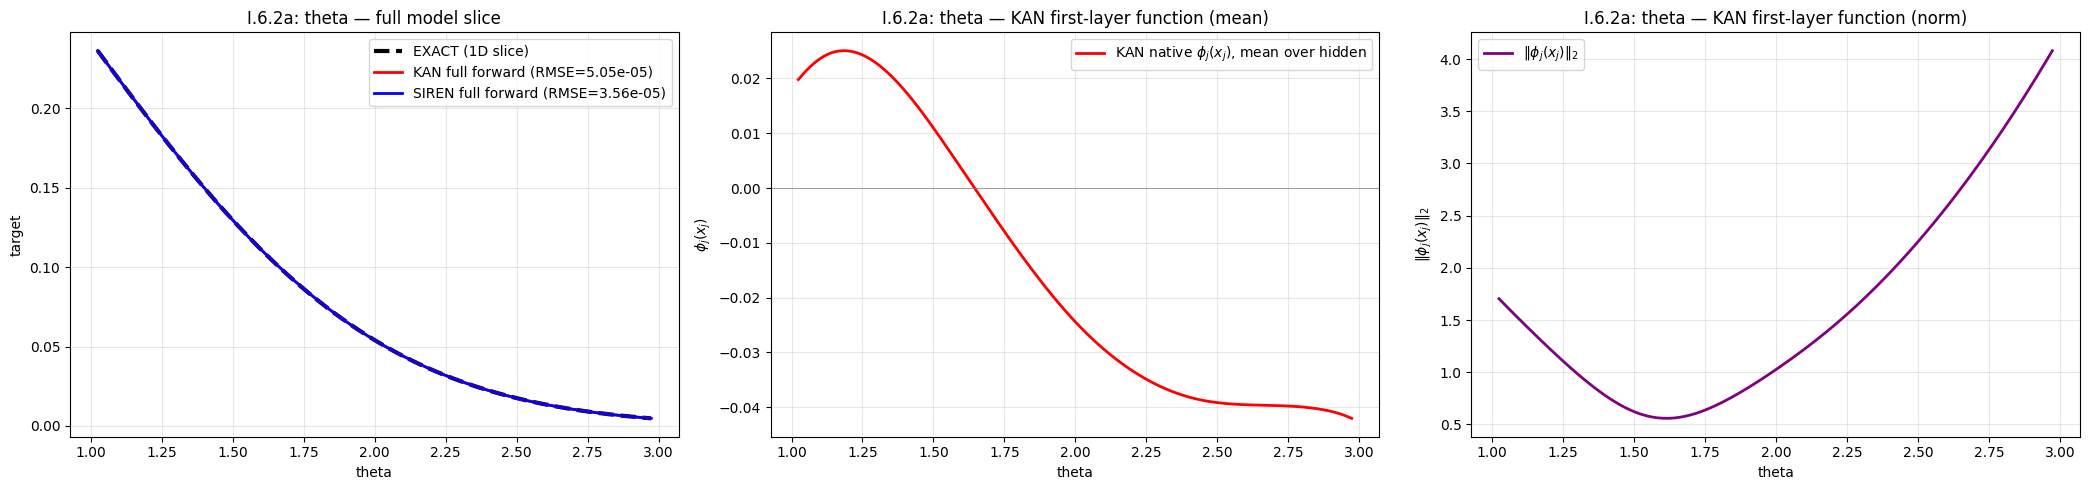


I.6.2: exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)
Features: ['sigma', 'theta']  n=5000
  KAN   | RMSE=0.00016  R²=0.99999  epochs=400  params=624
  SIREN | RMSE=0.00339  R²=0.99356  epochs=329  params=8577


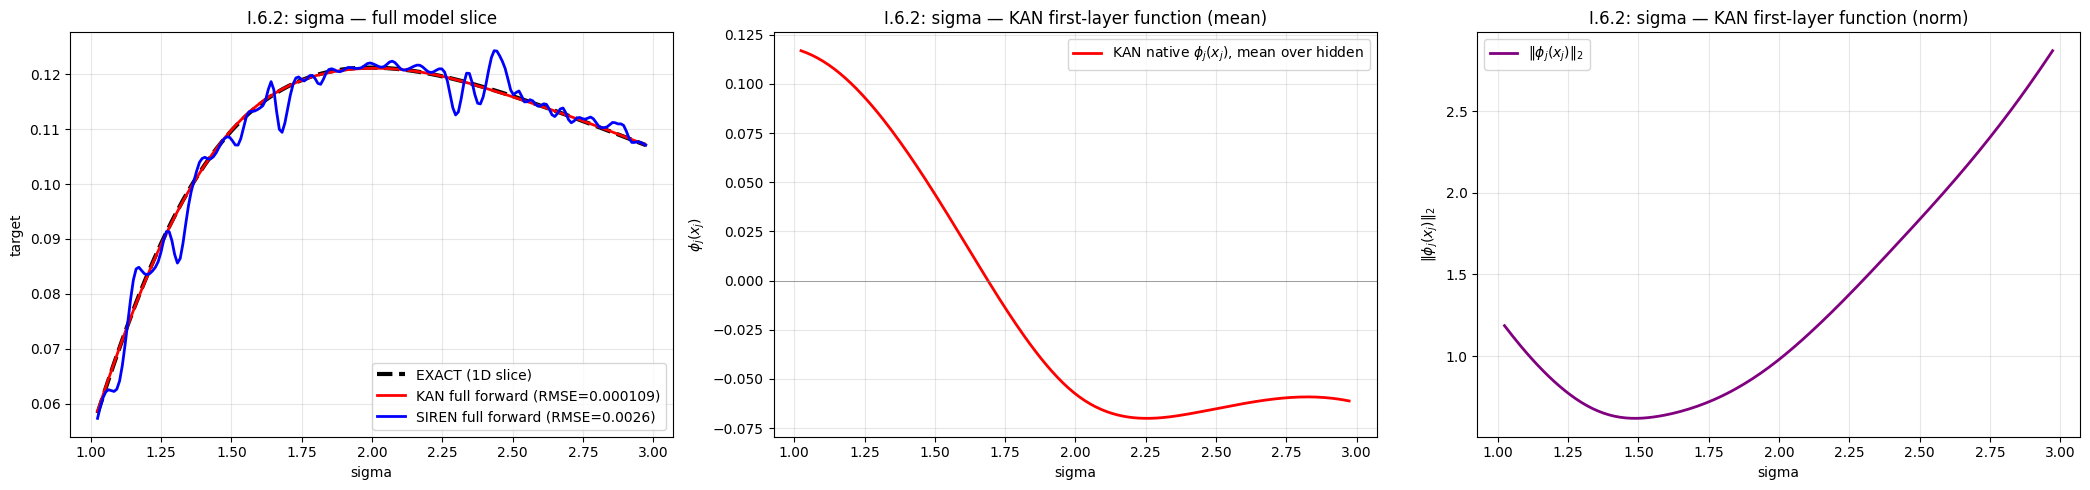

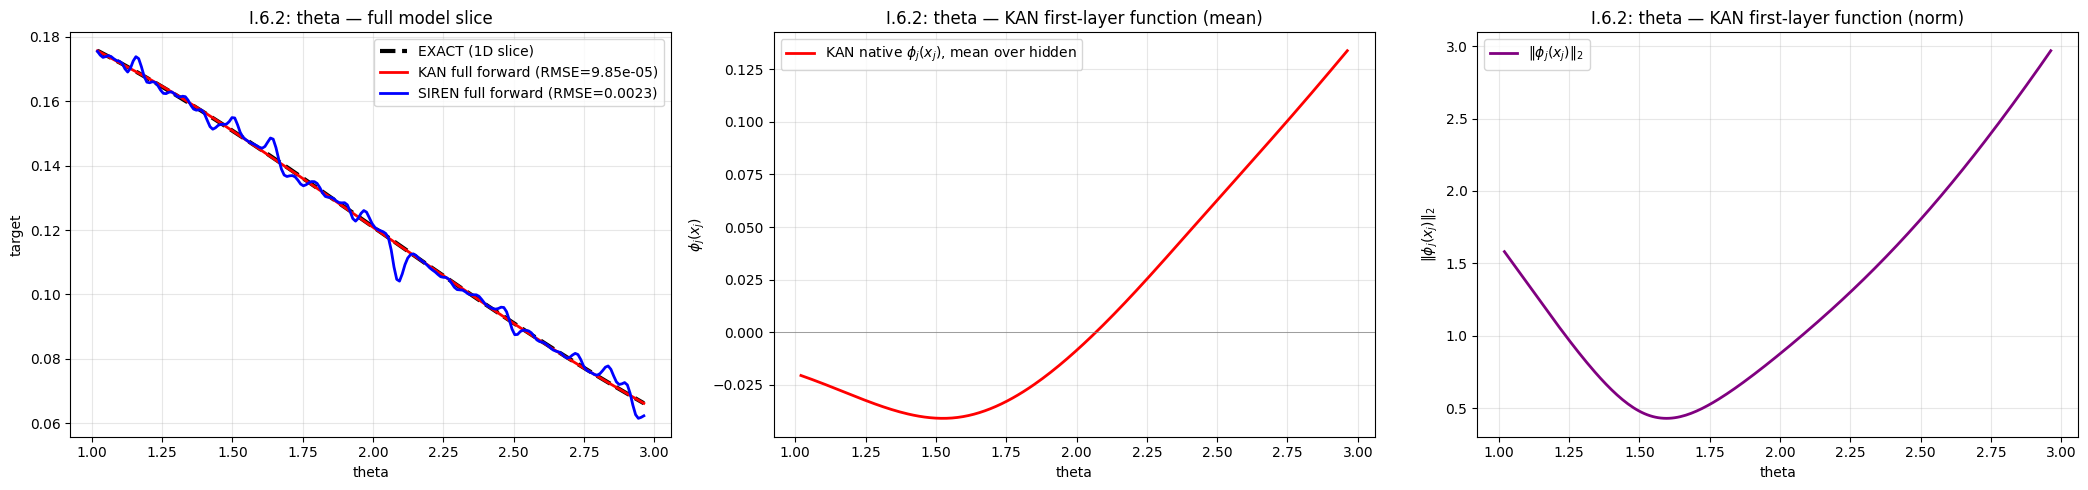


I.6.2b: exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*sigma)
Features: ['sigma', 'theta', 'theta1']  n=5000
  KAN   | RMSE=0.00039  R²=0.99996  epochs=400  params=832
  SIREN | RMSE=0.02815  R²=0.78806  epochs=174  params=8641


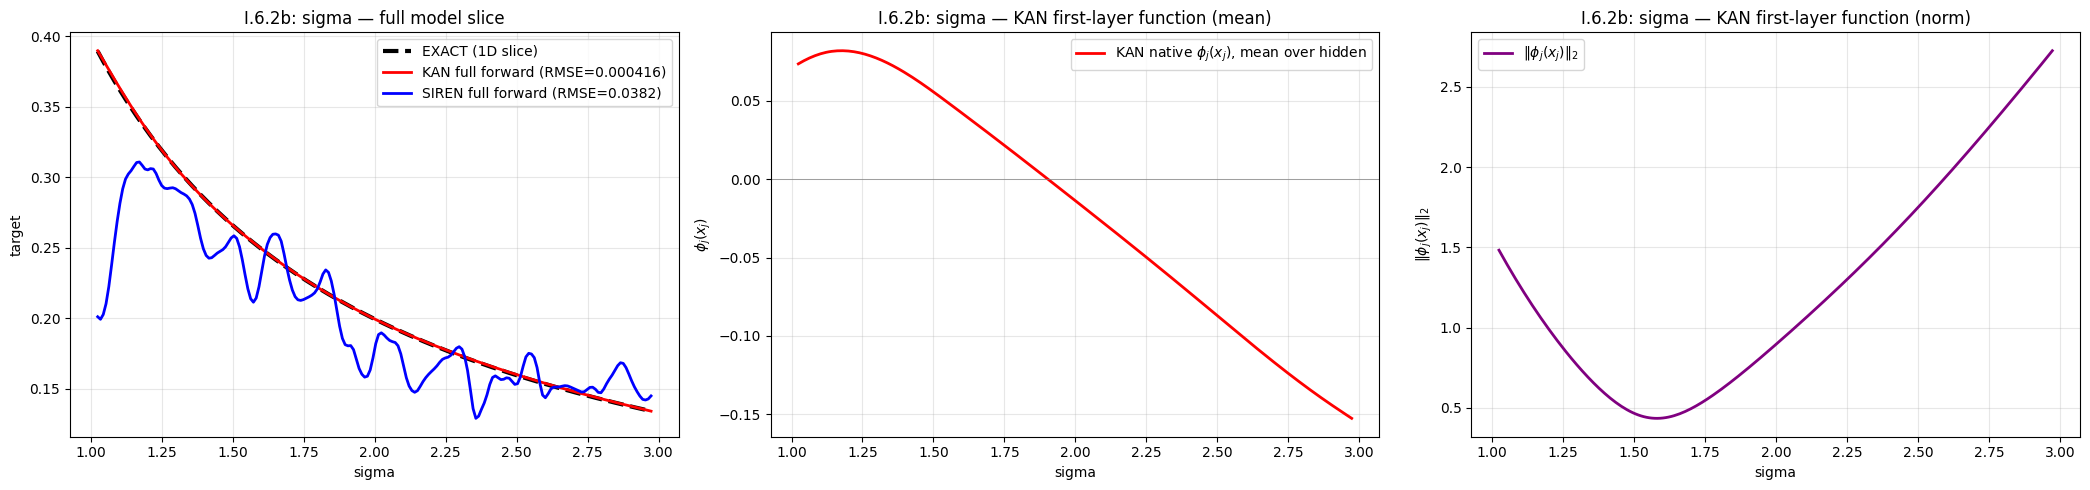

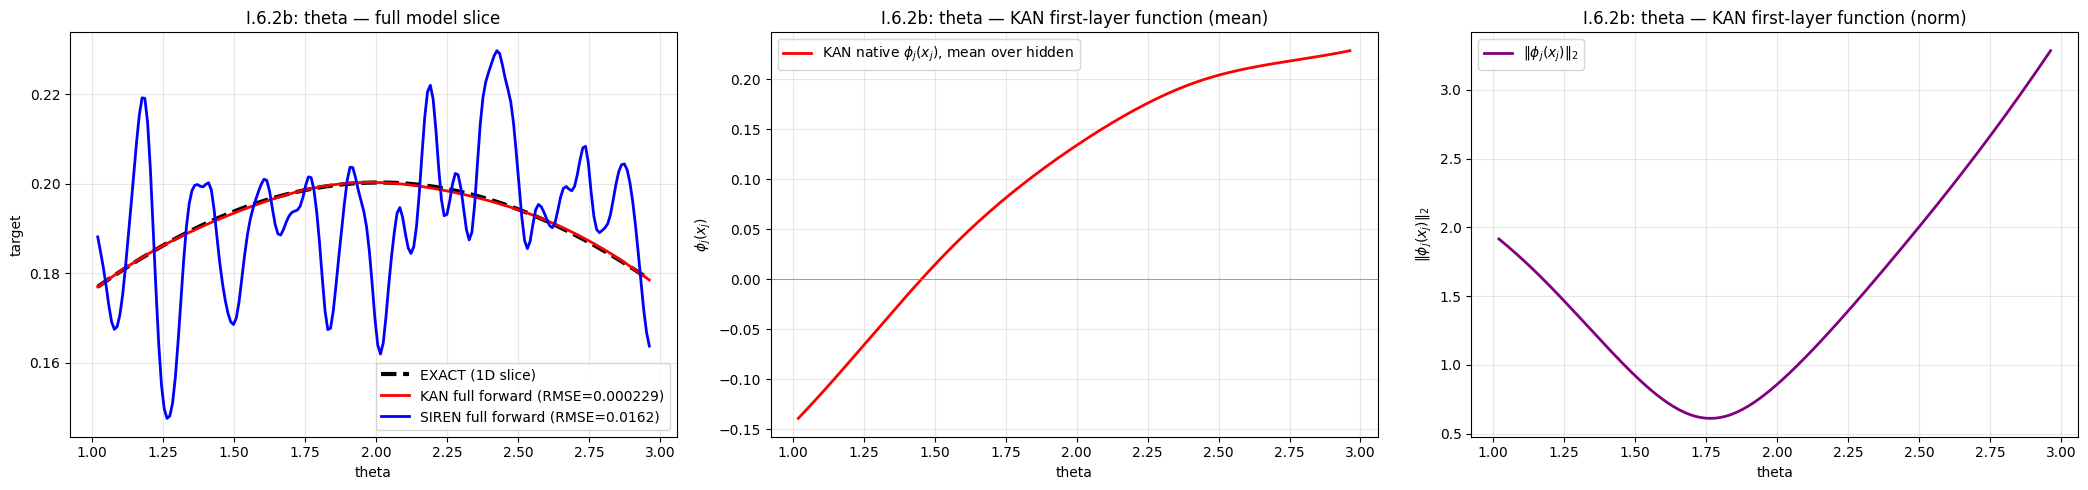

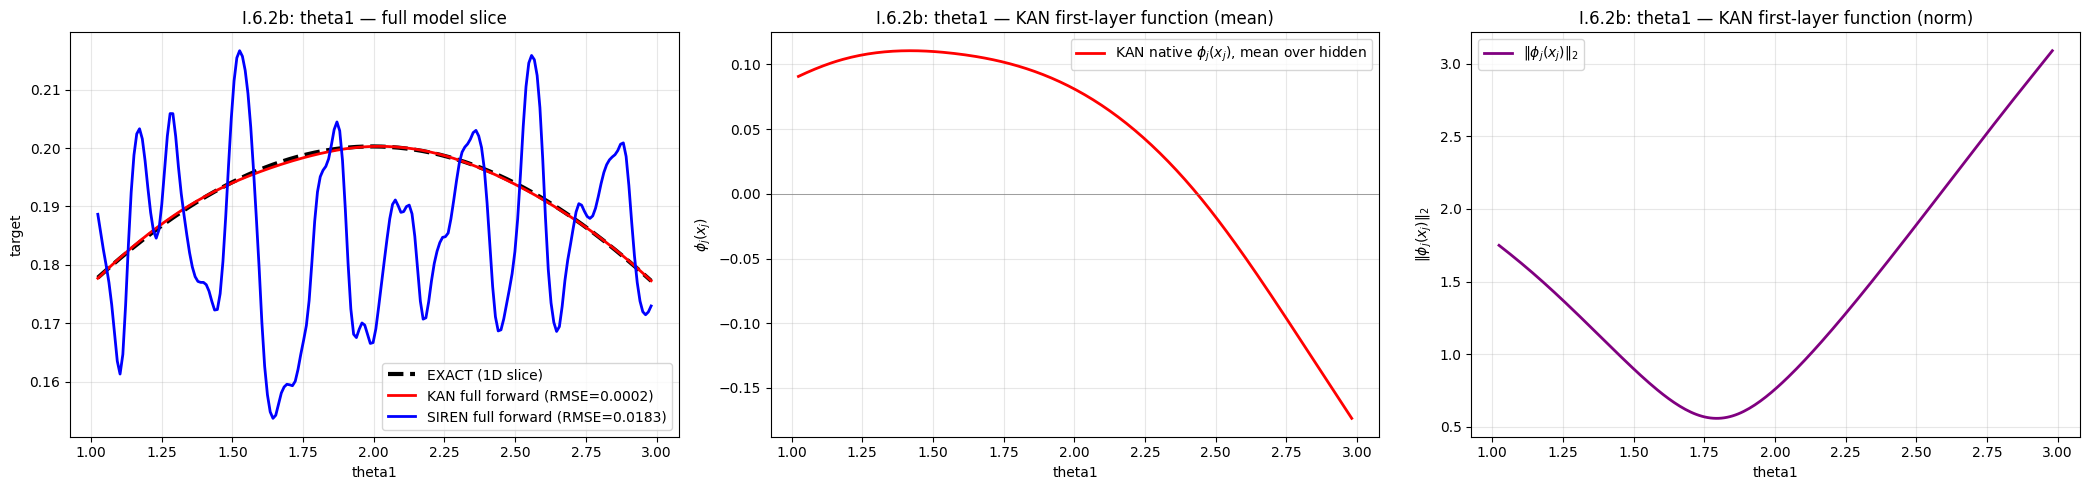


I.10.7: m_0/sqrt(1-v**2/c**2)
Features: ['m_0', 'v', 'c']  n=5000
  KAN   | RMSE=0.00245  R²=1.00000  epochs=400  params=832
  SIREN | RMSE=0.08358  R²=0.99508  epochs=243  params=8641


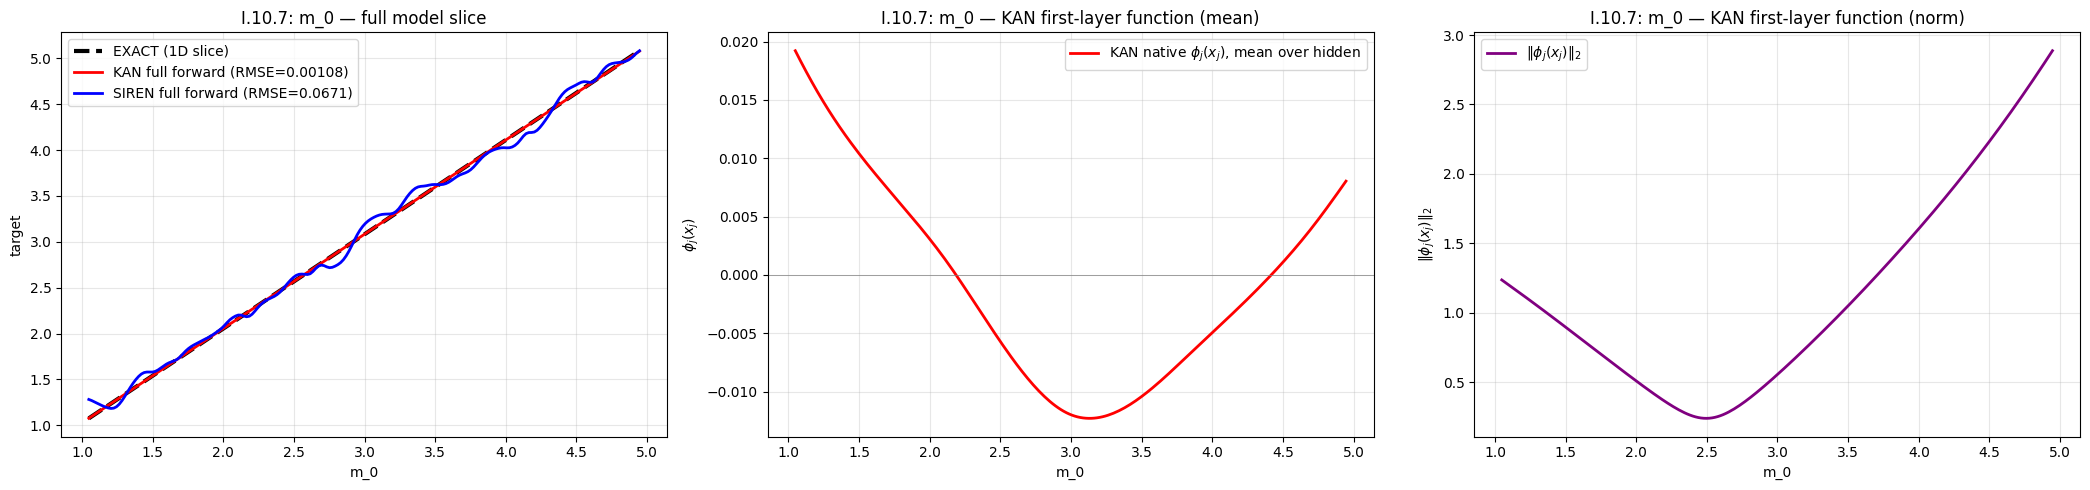

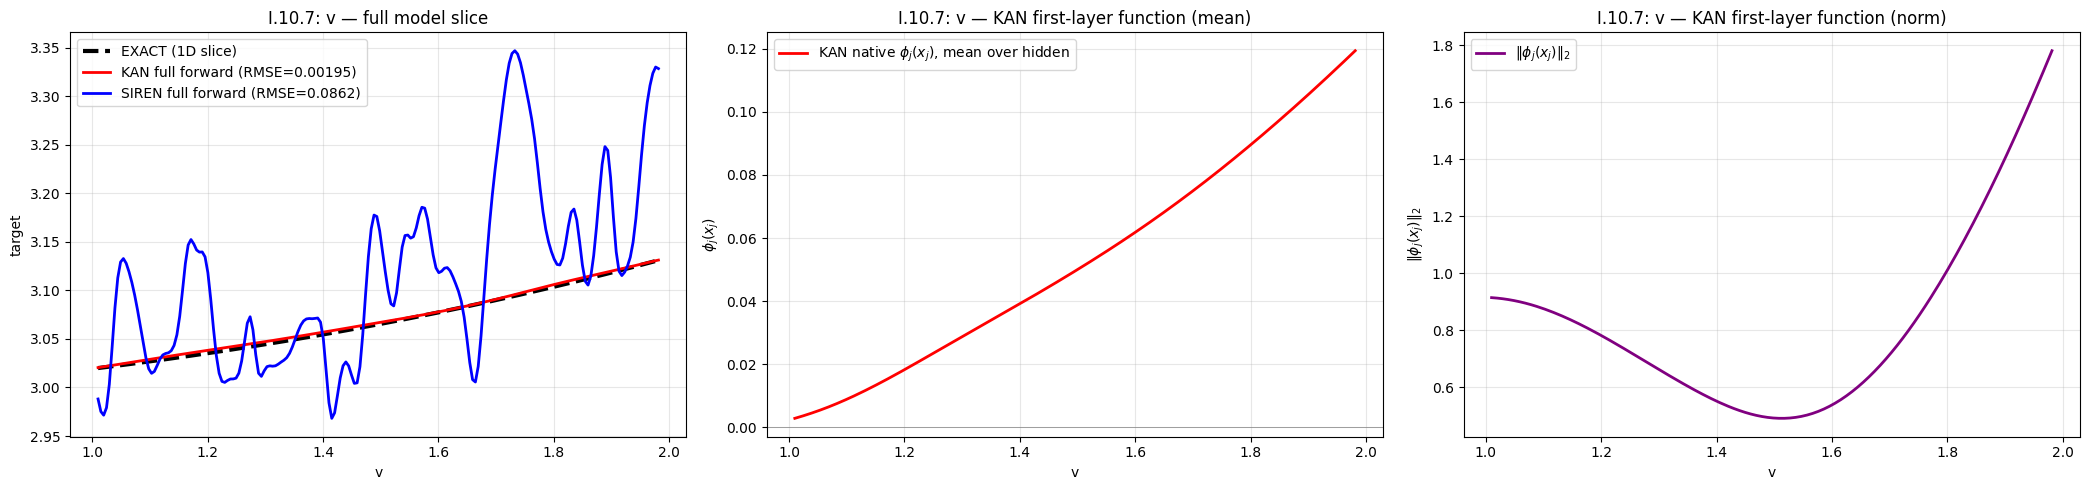

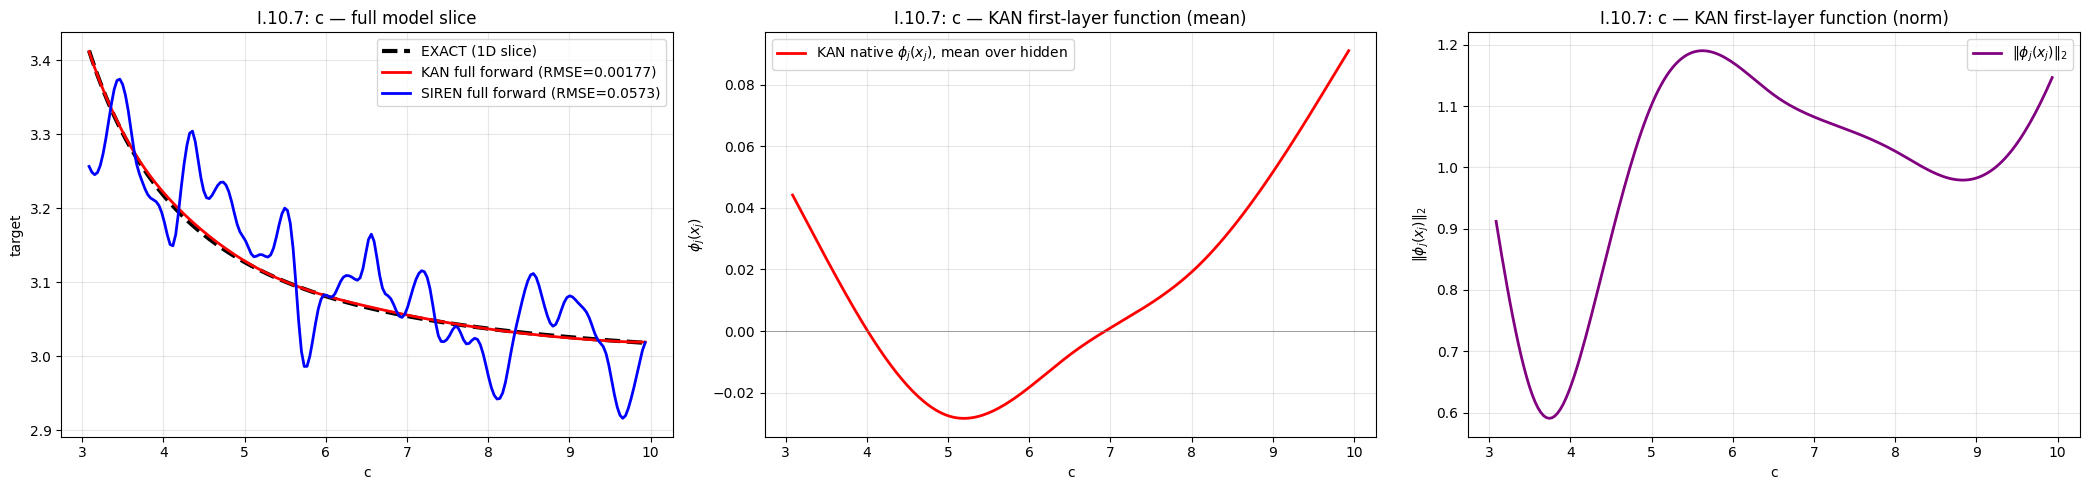

In [28]:
# ============================================================
# Выбираем 3-4 уравнения и запускаем эксперимент
# ============================================================

FEYNMAN_IDS = ["I.6.2a", "I.6.2", "I.6.2b", "I.10.7"]
# Либо: FEYNMAN_IDS = None  → первые подходящие автоматически

if FEYNMAN_IDS is not None:
    rows = catalog[catalog["Filename"].isin(FEYNMAN_IDS)].copy()
else:
    rows = catalog[catalog["# variables"] <= 3].head(3).copy()

results = {}
for _, row in rows.iterrows():
    try:
        res = run_feynman_kan_vs_siren(
            row,
            n_samples=5000,
            n_points=200,
            seed=42,
            kan_epochs=400,
            siren_epochs=400,
        )
        results[res["meta"]["id"]] = res
    except Exception as e:
        print(f"\nFAILED {row['Filename']}: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()

In [29]:
# ============================================================
# Итоговая таблица RMSE / R²
# ============================================================

rows_summary = []
for eq_id, res in results.items():
    m = res["metrics"]
    rows_summary.append({
        "equation": eq_id,
        "formula": res["meta"]["formula"][:60] + ("..." if len(res["meta"]["formula"]) > 60 else ""),
        "n_features": len(res["meta"]["variables"]),
        "KAN_RMSE":  m["kan_rmse"],
        "KAN_R2":    m["kan_r2"],
        "SIREN_RMSE": m["siren_rmse"],
        "SIREN_R2":   m["siren_r2"],
    })

df_summary = pd.DataFrame(rows_summary)
display(df_summary.round(5))

,equation,formula,n_features,KAN_RMSE,KAN_R2,SIREN_RMSE,SIREN_R2
0,I.6.2a,exp(-theta**2/2)/sqrt(2*pi),1,0.00005,1.00000,0.00004,1.00000
1,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2,0.00016,0.99999,0.00339,0.99356
2,I.6.2b,exp(-((theta-theta1)/sigma)**2/2)/(sqrt(2*pi)*...,3,0.00039,0.99996,0.02815,0.78806
3,I.10.7,m_0/sqrt(1-v**2/c**2),3,0.00245,1.00000,0.08358,0.99508
